In [49]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random


from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from tensorflow import keras
from typing import List
from keras.preprocessing.text import Tokenizer



## Import Data Sets

In [86]:
train_df = pd.read_csv("C:/Users/Mxf65s7/OneDrive - The Home Depot/Course Material/Data Science/Kaggle Competition/train.csv")
serving_df = pd.read_csv("C:/Users/Mxf65s7/OneDrive - The Home Depot/Course Material/Data Science/Kaggle Competition/test.csv")

train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Preprocessing

In [88]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [89]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
train_df = train_df.dropna()

In [94]:
## Tokenize the names
def preprocess(df):
    df = df.copy()
    
    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])
    
    def ticket_number(x):
        return x.split(" ")[-1]
        
    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])
    
    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)                     
    return df
    
preprocessed_train_df = preprocess(train_df)
preprocessed_serving_df = preprocess(serving_df)


preprocessed_train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
6,7,0,1,McCarthy Mr Timothy J,male,54.0,0,0,17463,51.8625,E46,S,17463,NONE
10,11,1,3,Sandstrom Miss Marguerite Rut,female,4.0,1,1,PP 9549,16.7000,G6,S,9549,PP
11,12,1,1,Bonnell Miss Elizabeth,female,58.0,0,0,113783,26.5500,C103,S,113783,NONE


In [95]:
input_features = list(preprocessed_train_df.columns)
input_features.remove("Ticket")
input_features.remove("PassengerId")
input_features.remove("Survived")
#input_features.remove("Ticket_number")

print(f"Input features: {input_features}")

Input features: ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Ticket_number', 'Ticket_item']


In [97]:


def tokenize_column(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """
    Tokenizes a column in a Pandas DataFrame into a list of names.
    """
    # Create a new column with the tokenized names
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df[column_name])
    df[f"{column_name}_tokenized"] = tokenizer.texts_to_sequences(df[column_name])
    return df

tokenize_column(preprocessed_train_df, 'Name')
tokenize_column(preprocessed_train_df, 'Sex')





,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item,Name_tokenized,Sex_tokenized
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC,"[122, 3, 5, 123, 124, 125, 12]",[2]
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE,"[45, 3, 24, 46, 47, 126, 127]",[2]
6,7,0,1,McCarthy Mr Timothy J,male,54.0,0,0,17463,51.8625,E46,S,17463,NONE,"[128, 1, 129, 25]",[1]
10,11,1,3,Sandstrom Miss Marguerite Rut,female,4.0,1,1,PP 9549,16.7000,G6,S,9549,PP,"[48, 2, 130, 131]",[2]
11,12,1,1,Bonnell Miss Elizabeth,female,58.0,0,0,113783,26.5500,C103,S,113783,NONE,"[132, 2, 7]",[2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,Beckwith Mrs Richard Leonard Sallie Monypeny,female,47.0,1,1,11751,52.5542,D35,S,11751,NONE,"[73, 3, 15, 74, 451, 60]",[2]
872,873,0,1,Carlsson Mr Frans Olof,male,33.0,0,0,695,5.0000,B51 B53 B55,S,695,NONE,"[452, 1, 453, 454]",[1]
879,880,1,1,Potter Mrs Thomas Jr Lily Alexenia Wilson,female,56.0,0,1,11767,83.1583,C50,C,11767,NONE,"[455, 3, 10, 23, 47, 456, 110]",[2]
887,888,1,1,Graham Miss Margaret Edith,female,19.0,0,0,112053,30.0000,B42,S,112053,NONE,"[33, 2, 11, 17]",[2]


In [98]:
preprocessed_train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Ticket_number',
       'Ticket_item', 'Name_tokenized', 'Sex_tokenized'],
      dtype='object')

In [158]:
preprocessed_train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item,Name_tokenized,Sex_tokenized
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC,"[122, 3, 5, 123, 124, 125, 12]",[2]
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE,"[45, 3, 24, 46, 47, 126, 127]",[2]
6,7,0,1,McCarthy Mr Timothy J,male,54.0,0,0,17463,51.8625,E46,S,17463,NONE,"[128, 1, 129, 25]",[1]
10,11,1,3,Sandstrom Miss Marguerite Rut,female,4.0,1,1,PP 9549,16.7000,G6,S,9549,PP,"[48, 2, 130, 131]",[2]
11,12,1,1,Bonnell Miss Elizabeth,female,58.0,0,0,113783,26.5500,C103,S,113783,NONE,"[132, 2, 7]",[2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,Beckwith Mrs Richard Leonard Sallie Monypeny,female,47.0,1,1,11751,52.5542,D35,S,11751,NONE,"[73, 3, 15, 74, 451, 60]",[2]
872,873,0,1,Carlsson Mr Frans Olof,male,33.0,0,0,695,5.0000,B51 B53 B55,S,695,NONE,"[452, 1, 453, 454]",[1]
879,880,1,1,Potter Mrs Thomas Jr Lily Alexenia Wilson,female,56.0,0,1,11767,83.1583,C50,C,11767,NONE,"[455, 3, 10, 23, 47, 456, 110]",[2]
887,888,1,1,Graham Miss Margaret Edith,female,19.0,0,0,112053,30.0000,B42,S,112053,NONE,"[33, 2, 11, 17]",[2]


In [176]:
# #Load Variables
# #identify x,y columns
# x = [c for c in preprocessed_train_df.columns if c not in  ['Survived','Name','Ticket_item','Sex','Ticket','Cabin','Embarked']]
# y = [c for c in preprocessed_train_df.columns if c in  ['Survived']]

# x_train, y_train = preprocessed_train_df[x].values, preprocessed_train_df[y].values


In [183]:
x= preprocessed_train_df.drop(['Survived','Name','Sex','Ticket','Cabin','Embarked','Ticket_item'], axis=1)

y= preprocessed_train_df['Survived']

x_train, y_train = x, y


## Random Forest Creation

In [184]:
classifier_rf = RandomForestClassifier(random_state=100, n_jobs=-1, max_depth=5,
                                       n_estimators=200, oob_score=True,)
classifier_rf.fit(x_train,y_train)

# checking the oob score
classifier_rf.oob_score_

ValueError: setting an array element with a sequence.

## Hyper Parameter Tuning

In [133]:
## Hyperparameter tuning 

rf = RandomForestClassifier(random_state=100, n_jobs=-1)

params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

from sklearn.model_selection import GridSearchCV

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 2,
                           n_jobs=-1, verbose=1, scoring="accuracy")

grid_search.fit(x_train, y_train)

Fitting 2 folds for each of 180 candidates, totalling 360 fits


c:\Users\Mxf65s7\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=2,
             estimator=RandomForestClassifier(n_jobs=-1, random_state=100),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [134]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=2, min_samples_leaf=10, n_estimators=10,
                       n_jobs=-1, random_state=100)

In [146]:
type(x.columns)

pandas.core.indexes.base.Index

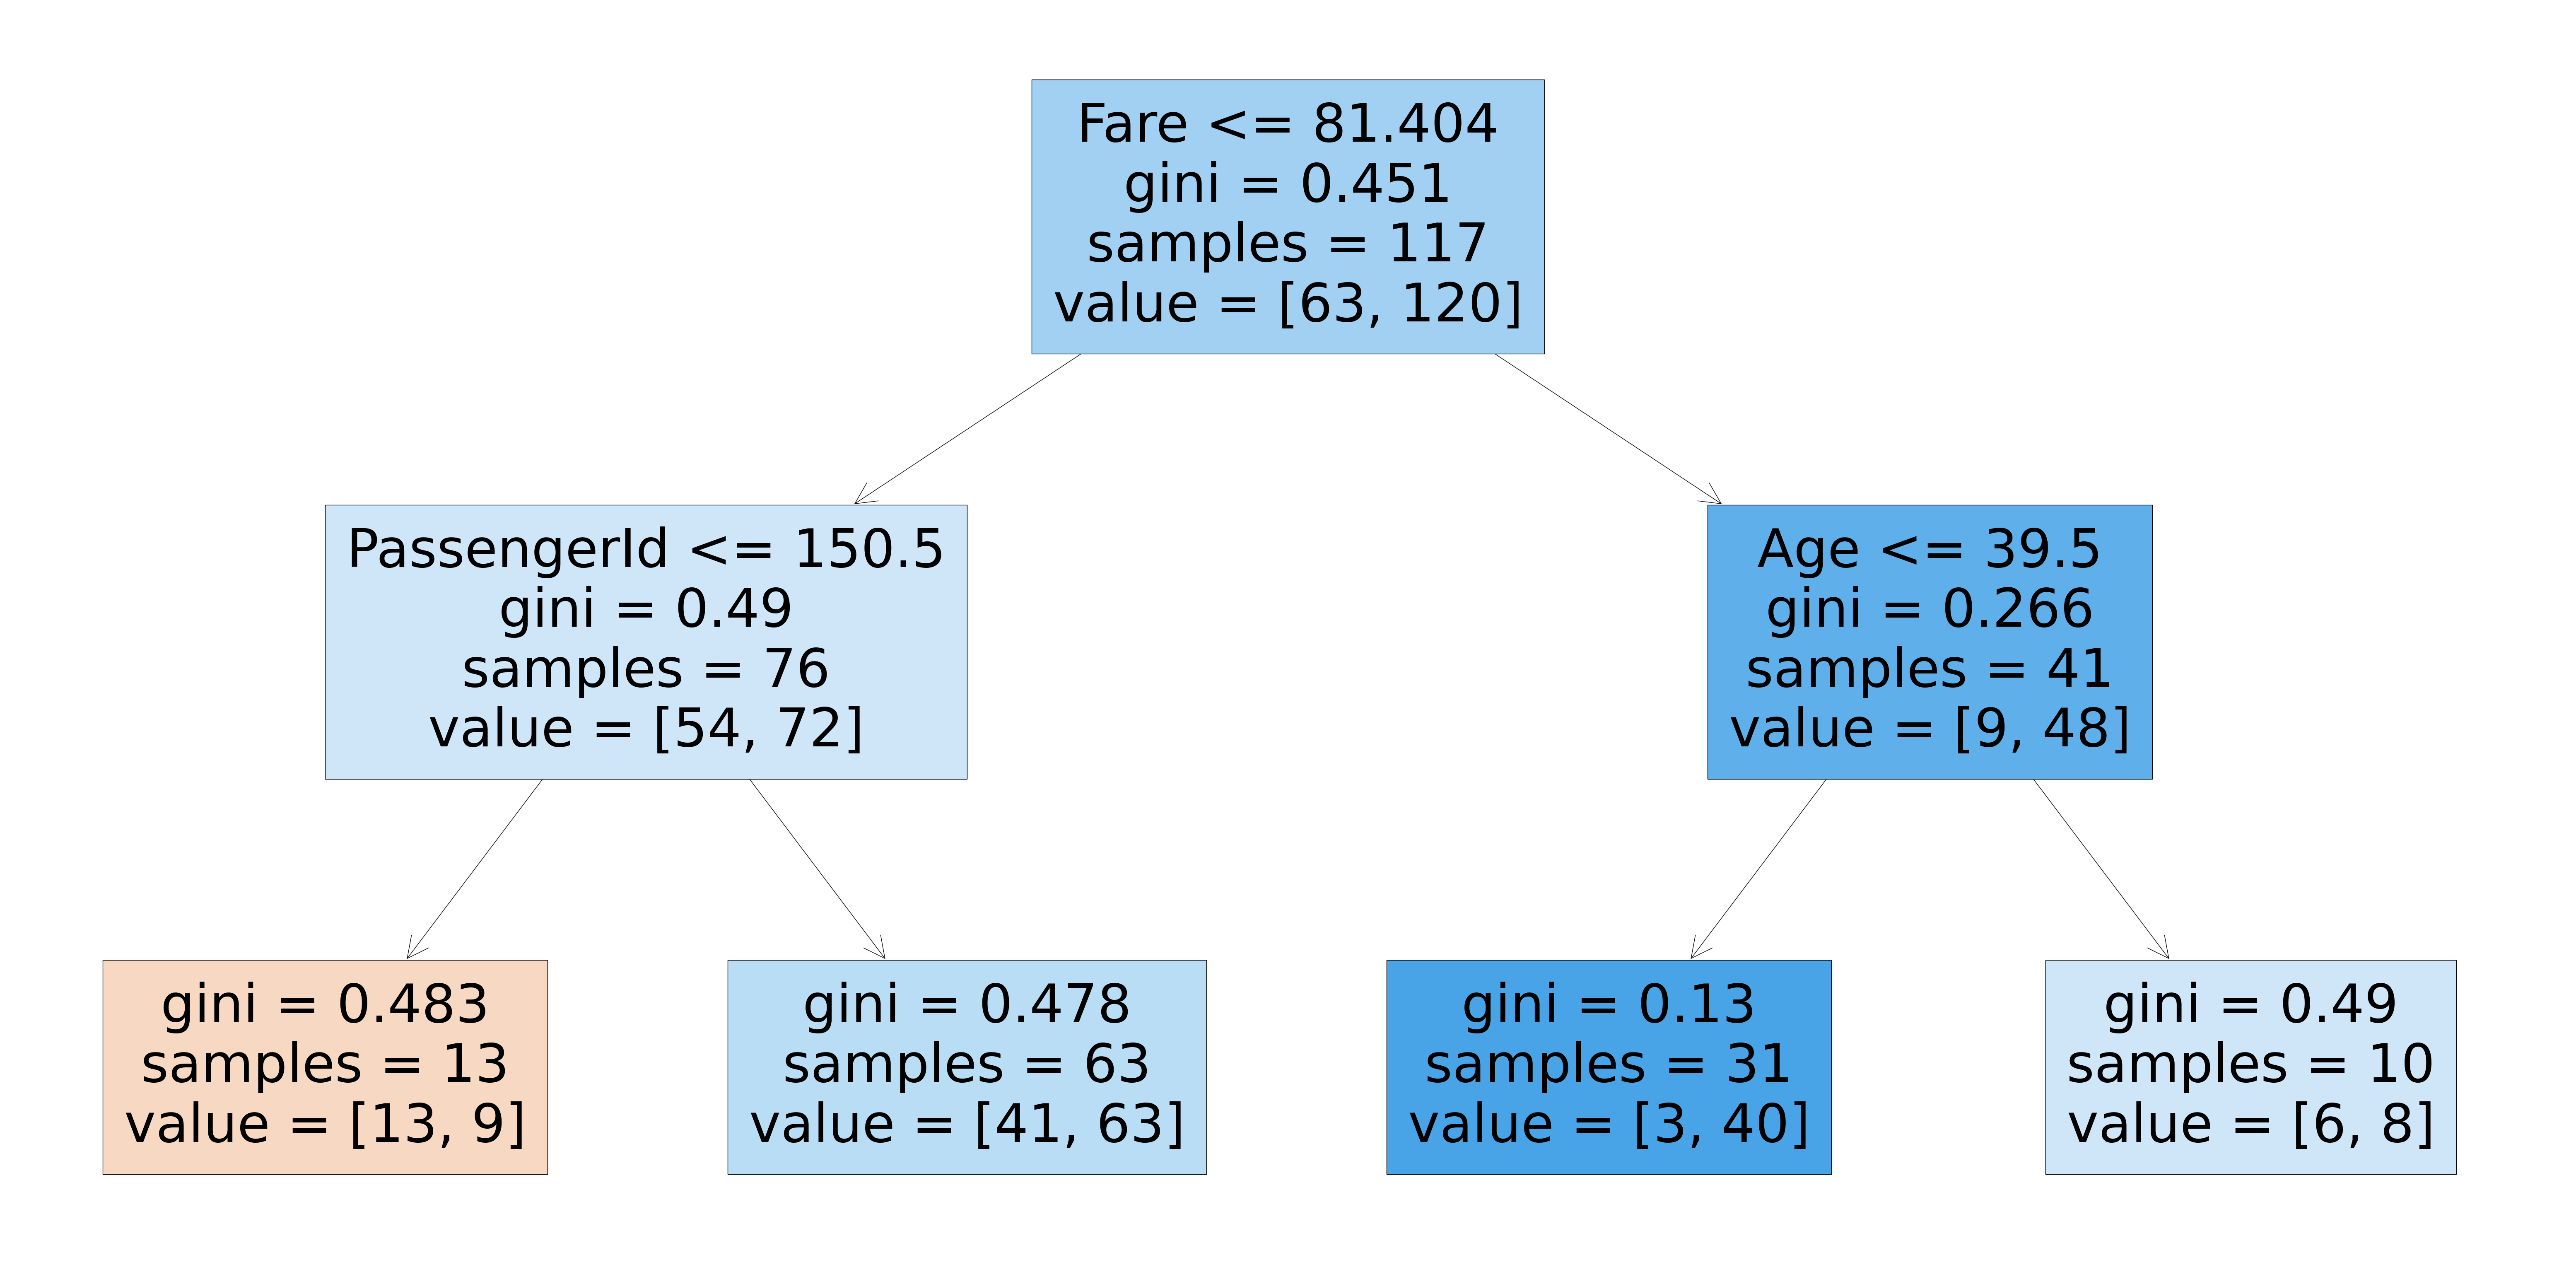

In [147]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[2], feature_names = x.columns.tolist(),filled=True);

In [148]:
rf_best.feature_importances_

array([0.26055189, 0.00302934, 0.35717111, 0.02906866, 0.17211772,
       0.17806129])

In [152]:
imp_df = pd.DataFrame({
    "Varname": x.columns.tolist(),
    "Imp": rf_best.feature_importances_
})

imp_df.sort_values(by="Imp", ascending=False).reset_index()

,index,Varname,Imp
0,2,Age,0.357171
1,0,PassengerId,0.260552
2,5,Fare,0.178061
3,4,Parch,0.172118
4,3,SibSp,0.029069
5,1,Pclass,0.003029


## Predictions

In [155]:
preprocessed_serving_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,892,3,Kelly Mr James,male,34.5,0,0,330911,7.8292,NaN,Q,330911,NONE
1,893,3,Wilkes Mrs James Ellen Needs,female,47.0,1,0,363272,7.0000,NaN,S,363272,NONE
2,894,2,Myles Mr Thomas Francis,male,62.0,0,0,240276,9.6875,NaN,Q,240276,NONE
3,895,3,Wirz Mr Albert,male,27.0,0,0,315154,8.6625,NaN,S,315154,NONE
4,896,3,Hirvonen Mrs Alexander Helga E Lindqvist,female,22.0,1,1,3101298,12.2875,NaN,S,3101298,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Spector Mr Woolf,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,3236,A.5.
414,1306,1,Oliva y Ocana Dona Fermina,female,39.0,0,0,PC 17758,108.9000,C105,C,17758,PC
415,1307,3,Saether Mr Simon Sivertsen,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,3101262,SOTON/O.Q.
416,1308,3,Ware Mr Frederick,male,NaN,0,0,359309,8.0500,NaN,S,359309,NONE


In [154]:
y_pred = grid_search.predict(serving_df)

c:\Users\Mxf65s7\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'Kelly, Mr. James'